<a href="https://colab.research.google.com/github/sajivjose174/Project/blob/main/OLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#OLA Case Study

##Problem Statement:
Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly. Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones. Tasked to predict whether a driver will be leaving the company or not based on their attributes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

In [ ]:
!curl -L -o ola_driver_scaler.csv "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1101k  100 1101k    0     0  4664k      0 --:--:-- --:--:-- --:--:-- 4666k


In [ ]:
df_ola=pd.read_csv('ola_driver_scaler.csv')

###Statisitical Summary:

In [ ]:
df_ola.shape

(19104, 14)

In [ ]:
df_ola.describe()

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [ ]:
cols=df_ola.columns
for i in cols:
  print(f'{i}:',df_ola[i].nunique())

Unnamed: 0: 19104
MMM-YY: 24
Driver_ID: 2381
Age: 36
Gender: 2
City: 29
Education_Level: 3
Income: 2383
Dateofjoining: 869
LastWorkingDate: 493
Joining Designation: 5
Grade: 5
Total Business Value: 10181
Quarterly Rating: 4


In [ ]:
for i in cols:
  print (f"{i}:", df_ola[i].value_counts())

Unnamed: 0: Unnamed: 0
19087    1
19086    1
19085    1
19084    1
19083    1
        ..
4        1
3        1
2        1
1        1
0        1
Name: count, Length: 19104, dtype: int64
MMM-YY: MMM-YY
01/01/19    1022
02/01/19     944
03/01/19     870
12/01/20     819
10/01/20     818
08/01/20     812
09/01/20     809
07/01/20     806
11/01/20     805
12/01/19     795
04/01/19     794
01/01/20     782
11/01/19     781
06/01/20     770
05/01/20     766
05/01/19     764
09/01/19     762
02/01/20     761
07/01/19     757
08/01/19     754
10/01/19     739
04/01/20     729
06/01/19     726
03/01/20     719
Name: count, dtype: int64
Driver_ID: Driver_ID
2784    24
2753    24
2771    24
1745    24
2766    24
        ..
136      1
138      1
2710     1
1744     1
2036     1
Name: count, Length: 2381, dtype: int64
Age: Age
36.0    1283
33.0    1250
34.0    1234
30.0    1146
32.0    1143
35.0    1138
31.0    1076
29.0    1013
37.0     862
38.0     854
39.0     788
28.0     772
27.0     744
40.0  

In [ ]:
df_ola.isnull().sum()

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


In [ ]:
#Grouping and aggregating:

df1=df_ola.groupby('Driver_ID').agg(Reporting_Months=('MMM-YY','nunique'),
                                  Age=('Age','first'),
                                  Gender=('Gender','first'),
                                  City=('City','first'),
                                  Education_Level=('Education_Level','first'),
                                  Income=('Income','mean'),
                                  Date_Of_Joining=('Dateofjoining','first'),

                                  Last_Working_Date=('LastWorkingDate','last'),
                                  Joining_Designation=('Joining Designation','first'),
                                  Grade=('Grade',lambda x: x.mode()[0]),
                                  Total_Business_Value=('Total Business Value','sum'),
                                  Quarterly_Rating=('Quarterly Rating','mean')).reset_index()

In [ ]:
df1.shape

(2381, 13)

In [ ]:
#New Feature:

df1['Avg_Business_per_Month']=df1['Total_Business_Value']/df1['Reporting_Months']

In [ ]:
df1['Last_Working_Date']=pd.to_datetime(df1['Last_Working_Date'])
df1['Date_Of_Joining']=pd.to_datetime(df1['Date_Of_Joining'])

/tmp/ipython-input-736392924.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Last_Working_Date']=pd.to_datetime(df1['Last_Working_Date'])
/tmp/ipython-input-736392924.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Date_Of_Joining']=pd.to_datetime(df1['Date_Of_Joining'])


In [ ]:
df1['Tenure_in_Months']=df1['Last_Working_Date']-df1['Date_Of_Joining']

In [ ]:
#New Feature:

df1['Tenure_in_Months'] = ((df1['Last_Working_Date'].dt.year - df1['Date_Of_Joining'].dt.year) * 12+ (df1['Last_Working_Date'].dt.month - df1['Date_Of_Joining'].dt.month))

In [ ]:
y1 = df1['Date_Of_Joining'].dt.year
m1 = df1['Date_Of_Joining'].dt.month
d1 = df1['Date_Of_Joining'].dt.day

y2 = df1['Last_Working_Date'].dt.year
m2 = df1['Last_Working_Date'].dt.month
d2 = df1['Last_Working_Date'].dt.day

df1['Tenure_in_Months'] = (y2 - y1) * 12 + (m2 - m1) - (d2 < d1).astype(int)

In [ ]:
df1.isnull().sum()

,0
Driver_ID,0
Reporting_Months,0
Age,0
Gender,0
City,0
Education_Level,0
Income,0
Date_Of_Joining,0
Last_Working_Date,765
Joining_Designation,0


In [ ]:
df1['Attrition']=np.where(df1['Last_Working_Date'].isna(),0,1)

In [ ]:
df1

,Driver_ID,Reporting_Months,Age,Gender,City,Education_Level,Income,Date_Of_Joining,Last_Working_Date,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating,Avg_Business_per_Month,Tenure_in_Months,Attrition
0,1,3,28.0,0.0,C23,2,57387.0,2018-12-24,2019-03-11,1,1,1715580,2.000000,571860.000000,2.0,1
1,2,2,31.0,0.0,C7,2,67016.0,2020-11-06,NaT,2,2,0,1.000000,0.000000,NaN,0
2,4,5,43.0,0.0,C13,2,65603.0,2019-12-07,2020-04-27,2,2,350000,1.000000,70000.000000,4.0,1
3,5,3,29.0,0.0,C9,0,46368.0,2019-01-09,2019-03-07,1,1,120360,1.000000,40120.000000,1.0,1
4,6,5,31.0,1.0,C11,1,78728.0,2020-07-31,NaT,3,3,1265000,1.600000,253000.000000,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2784,24,33.0,0.0,C24,0,82815.0,2015-10-15,NaT,2,3,21748820,2.625000,906200.833333,NaN,0
2377,2785,3,34.0,1.0,C9,0,12105.0,2020-08-28,2020-10-28,1,1,0,1.000000,0.000000,2.0,1
2378,2786,9,44.0,0.0,C19,0,35370.0,2018-07-31,2019-09-22,2,2,2815090,1.666667,312787.777778,13.0,1
2379,2787,6,28.0,1.0,C20,2,69498.0,2018-07-21,2019-06-20,1,1,977830,1.500000,162971.666667,10.0,1


In [ ]:
df2=df1.copy()

In [ ]:
df2.drop(columns=['Date_Of_Joining','Last_Working_Date'],inplace=True)

In [ ]:
df2=df2.drop(columns='Driver_ID')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df2['City'] = le.fit_transform(df1['City'])

In [ ]:
df2['Tenure_in_Months']=df2['Tenure_in_Months'].fillna(0)

In [ ]:
df2

,Reporting_Months,Age,Gender,City,Education_Level,Income,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating,Avg_Business_per_Month,Tenure_in_Months,Attrition
0,3,28.0,0.0,15,2,57387.0,1,1,1715580,2.000000,571860.000000,2.0,1
1,2,31.0,0.0,26,2,67016.0,2,2,0,1.000000,0.000000,0.0,0
2,5,43.0,0.0,4,2,65603.0,2,2,350000,1.000000,70000.000000,4.0,1
3,3,29.0,0.0,28,0,46368.0,1,1,120360,1.000000,40120.000000,1.0,1
4,5,31.0,1.0,2,1,78728.0,3,3,1265000,1.600000,253000.000000,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,24,33.0,0.0,16,0,82815.0,2,3,21748820,2.625000,906200.833333,0.0,0
2377,3,34.0,1.0,28,0,12105.0,1,1,0,1.000000,0.000000,2.0,1
2378,9,44.0,0.0,10,0,35370.0,2,2,2815090,1.666667,312787.777778,13.0,1
2379,6,28.0,1.0,12,2,69498.0,1,1,977830,1.500000,162971.666667,10.0,1


In [ ]:
df2['Gender']=df2['Gender'].astype('int64')
df2

,Reporting_Months,Age,Gender,City,Education_Level,Income,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating,Avg_Business_per_Month,Tenure_in_Months,Attrition
0,3,28.0,0,15,2,57387.0,1,1,1715580,2.000000,571860.000000,2.0,1
1,2,31.0,0,26,2,67016.0,2,2,0,1.000000,0.000000,0.0,0
2,5,43.0,0,4,2,65603.0,2,2,350000,1.000000,70000.000000,4.0,1
3,3,29.0,0,28,0,46368.0,1,1,120360,1.000000,40120.000000,1.0,1
4,5,31.0,1,2,1,78728.0,3,3,1265000,1.600000,253000.000000,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,24,33.0,0,16,0,82815.0,2,3,21748820,2.625000,906200.833333,0.0,0
2377,3,34.0,1,28,0,12105.0,1,1,0,1.000000,0.000000,2.0,1
2378,9,44.0,0,10,0,35370.0,2,2,2815090,1.666667,312787.777778,13.0,1
2379,6,28.0,1,12,2,69498.0,1,1,977830,1.500000,162971.666667,10.0,1


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

num_cols = ['Tenure_in_Months', 'Reporting_Months', 'Income','Avg_Business_per_Month', 'Total_Business_Value', 'Age']
df_knn = df1[num_cols].copy()
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_knn)
imputer = KNNImputer(n_neighbors=5)
df_imputed_scaled = imputer.fit_transform(df_scaled)
df_imputed = scaler.inverse_transform(df_imputed_scaled)
df_imputed = pd.DataFrame(df_imputed, columns=num_cols)
df_imputed.isnull().sum()


#Although the dataset did not have missing numeric values, KNN imputation was demonstrated using scaled features to show distance-based imputation readiness.

,0
Tenure_in_Months,0
Reporting_Months,0
Income,0
Avg_Business_per_Month,0
Total_Business_Value,0
Age,0


###Plots:

/tmp/ipython-input-1660943682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x=col, palette='pastel')
/tmp/ipython-input-1660943682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x=col, palette='pastel')
/tmp/ipython-input-1660943682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x=col, palette='pastel')
/tmp/ipython-input-1660943682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

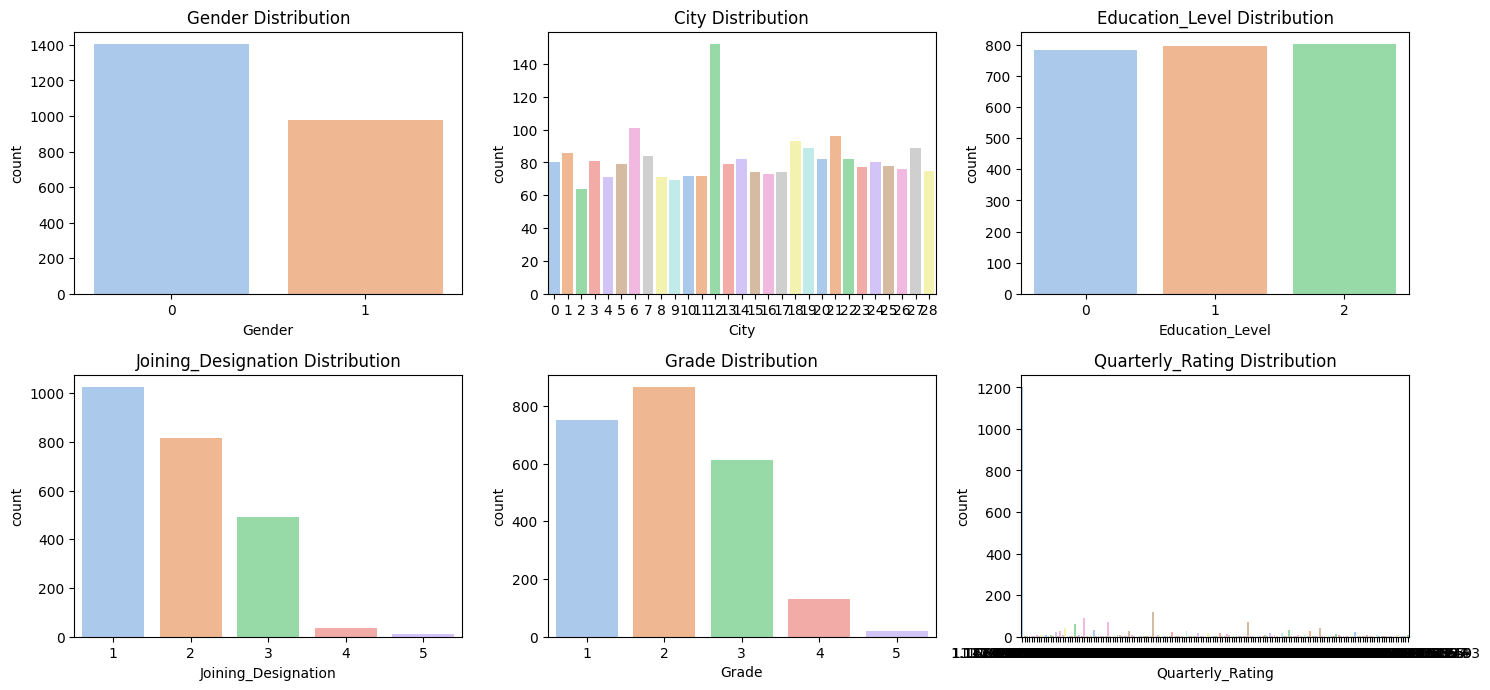

In [ ]:
#Univariate Analysis:

cat_cols = ['Gender', 'City', 'Education_Level', 'Joining_Designation', 'Grade','Quarterly_Rating']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df2, x=col, palette='pastel')
    plt.title(f'{col} Distribution')
    plt.tight_layout()
plt.show()

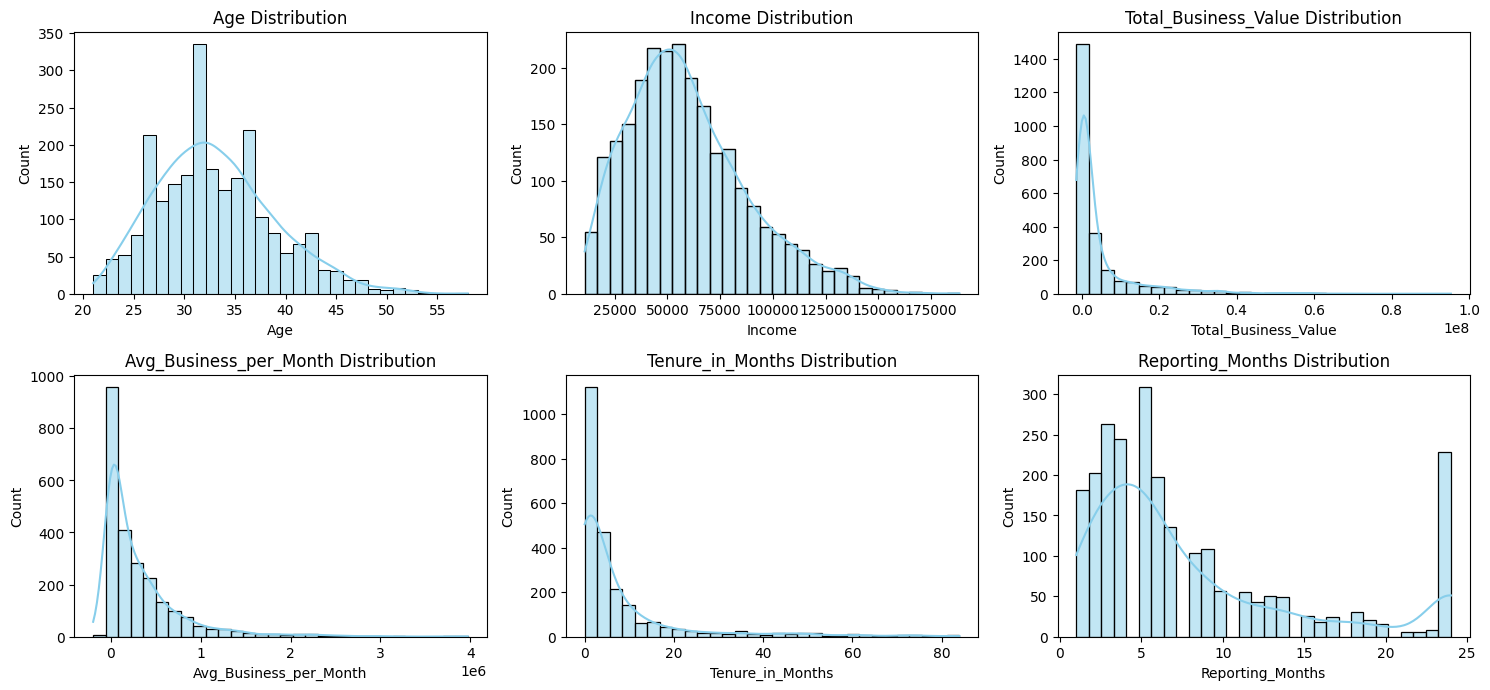

In [ ]:
#Univariate Analysis:

num_cols = ['Age', 'Income', 'Total_Business_Value', 'Avg_Business_per_Month', 'Tenure_in_Months', 'Reporting_Months']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df2[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Distribution')
    plt.tight_layout()
plt.show()

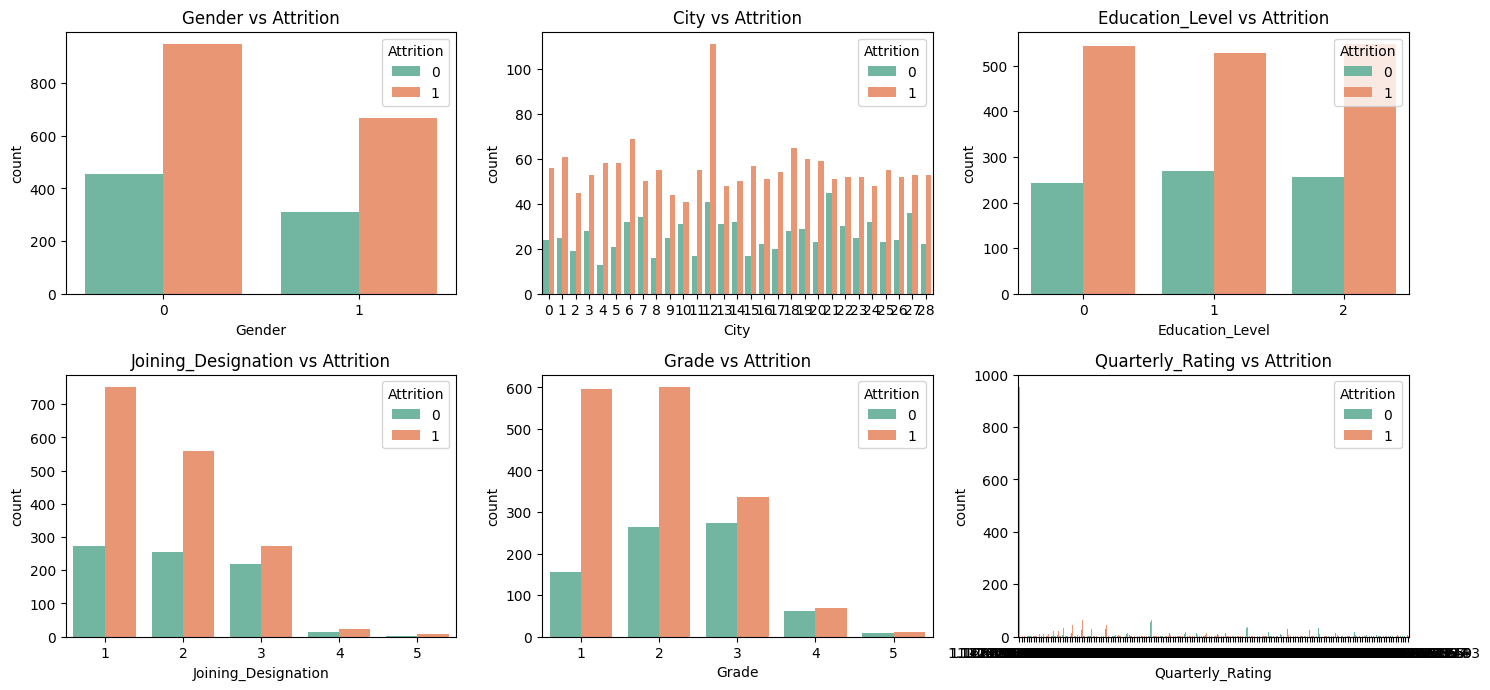

In [ ]:
#Bivariate Analysis:

cat_cols1 = ['Gender', 'City', 'Education_Level', 'Joining_Designation', 'Grade', 'Quarterly_Rating']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols1, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df2, x=col, hue='Attrition', palette='Set2')
    plt.title(f'{col} vs Attrition')
    plt.tight_layout()
plt.show()

/tmp/ipython-input-551475045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='Attrition', y=col, palette='coolwarm')
/tmp/ipython-input-551475045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='Attrition', y=col, palette='coolwarm')
/tmp/ipython-input-551475045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='Attrition', y=col, palette='coolwarm')
/tmp/ipython-input-551475045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

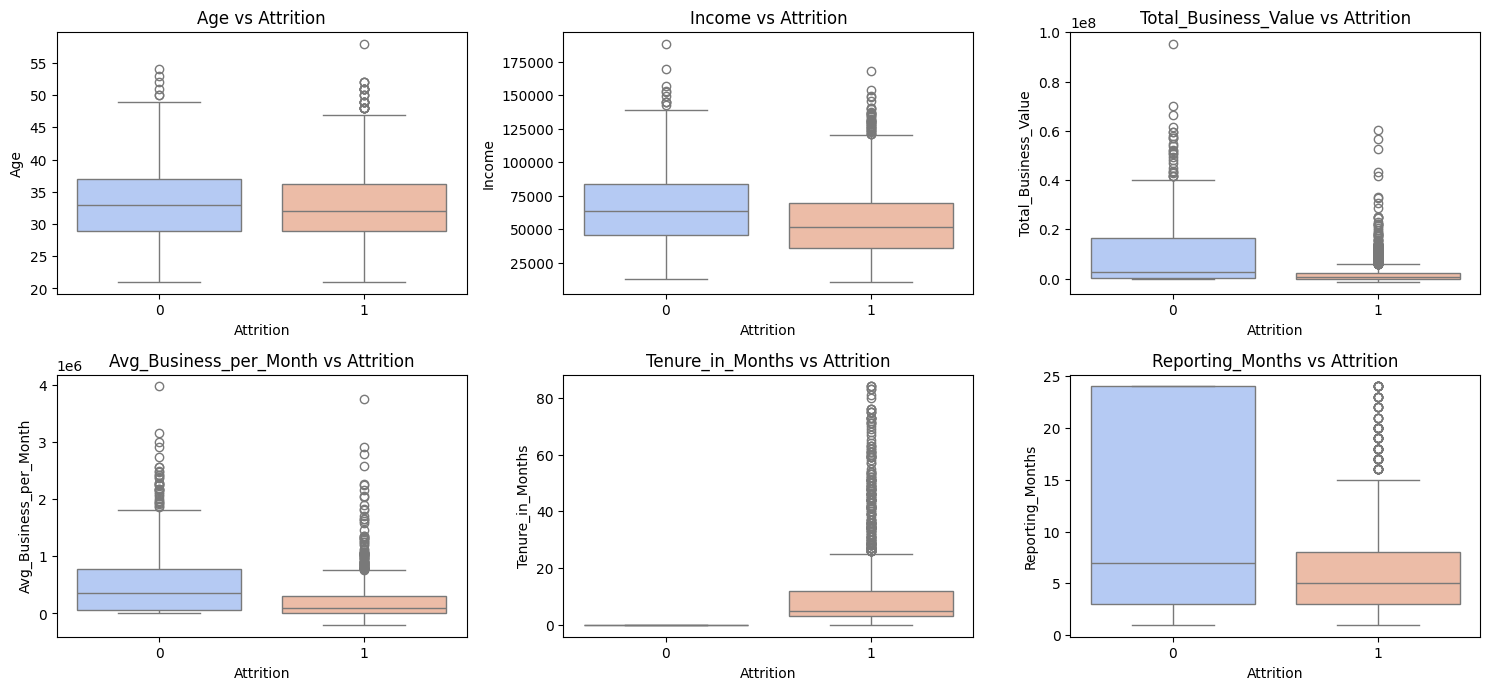

In [ ]:
#Bivariate Analysis:

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df2, x='Attrition', y=col, palette='coolwarm')
    plt.title(f'{col} vs Attrition')
    plt.tight_layout()
plt.show()

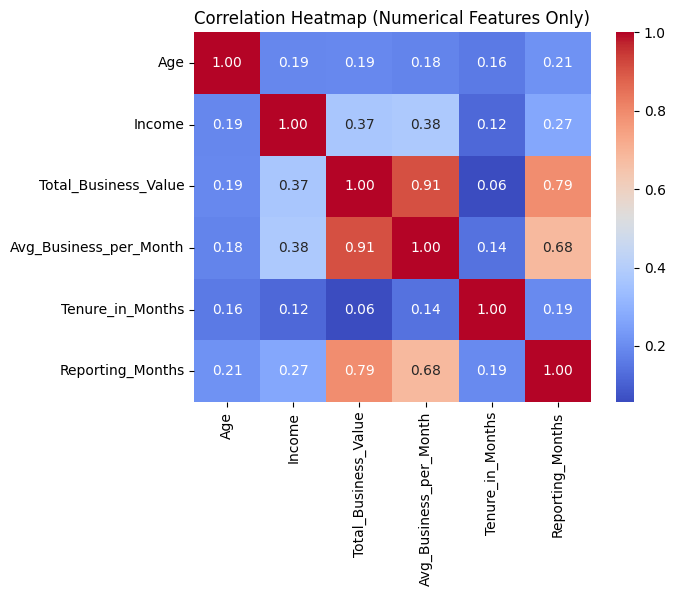

In [ ]:
num_cols = ['Age', 'Income', 'Total_Business_Value', 'Avg_Business_per_Month', 'Tenure_in_Months', 'Reporting_Months']
corr = df2[num_cols].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
cat_cols = ['Gender', 'City', 'Education_Level', 'Joining_Designation', 'Grade','Quarterly_Rating']
for col in cat_cols:
    contingency_table = pd.crosstab(df2[col], df2['Attrition'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"\nChi-Square Test between {col} and Attrition:")
    print(f"Chi2 Statistic = {chi2:.3f}, p-value = {p:.4f}")

    if p < 0.05:
        print("Significant relationship (Reject H₀: Not Independent)")
    else:
        print(" ot significant (Fail to reject H₀: Independent)")


Chi-Square Test between Gender and Attrition:
Chi2 Statistic = 0.154, p-value = 0.6944
 ot significant (Fail to reject H₀: Independent)

Chi-Square Test between City and Attrition:
Chi2 Statistic = 46.917, p-value = 0.0140
Significant relationship (Reject H₀: Not Independent)

Chi-Square Test between Education_Level and Attrition:
Chi2 Statistic = 1.525, p-value = 0.4664
 ot significant (Fail to reject H₀: Independent)

Chi-Square Test between Joining_Designation and Attrition:
Chi2 Statistic = 49.141, p-value = 0.0000
Significant relationship (Reject H₀: Not Independent)

Chi-Square Test between Grade and Attrition:
Chi2 Statistic = 106.137, p-value = 0.0000
Significant relationship (Reject H₀: Not Independent)

Chi-Square Test between Quarterly_Rating and Attrition:
Chi2 Statistic = 562.020, p-value = 0.0000
Significant relationship (Reject H₀: Not Independent)


In [ ]:
#Attrition is significantly related to variables like City, Joining_Designation, Grade, and Quarterly_Rating.
#Gender and Education_Level show no significant relationship with attrition.


#Quarterly_Rating-Attrition depends on Quarterly Rating (Strong)
#City-Attrition depends on City(significant)
#Joining_Designation-Attrition depends on Joining Designation(significant)
#Grade-Attrition depends on Grade(significant)

In [ ]:
X = df2.drop(columns=['Attrition'])
y = df2['Attrition']

<Axes: xlabel='Attrition', ylabel='count'>

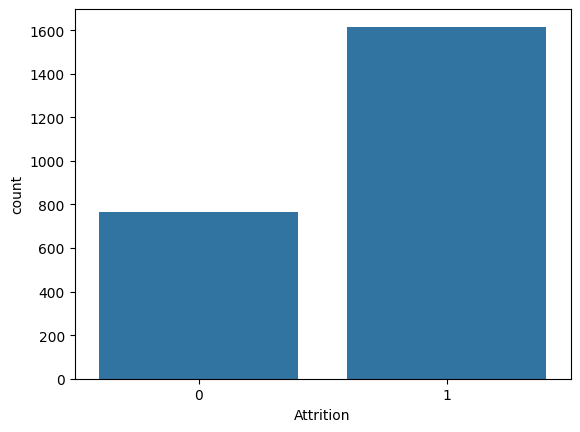

In [ ]:
#Data Imbalance check:
sns.countplot(data=df2,x='Attrition')

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Attrition
1    1289
0     615
Name: count, dtype: int64
After SMOTE: Attrition
0    1289
1    1289
Name: count, dtype: int64


###Random Forest (Bagging):

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params = {
          'n_estimators' : [100,200,300,400],
          'max_depth' : [3,5,10],
          'criterion' : ['gini', 'entropy'],
          'bootstrap' : [True, False],
          'max_features' : [8,9,10]
         }
grid=GridSearchCV(estimator=RandomForestClassifier(),param_grid=params,scoring='accuracy',cv=3,n_jobs=-1)

In [ ]:
grid.fit(X_train_res,y_train_res)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10], 'max_features': [8, 9, 10],
                         'n_estimators': [100, 200, 300, 400]},
             scoring='accuracy')

In [ ]:
print("Best params: ", grid.best_params_)
print("Best score: ", grid.best_score_)

Best params:  {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 8, 'n_estimators': 100}
Best score:  0.9825455054101128


In [ ]:
rf=grid.best_estimator_

In [ ]:
rf.fit(X_train_res,y_train_res)

RandomForestClassifier(criterion='entropy', max_depth=5, max_features=8)

In [ ]:
y_pred=rf.predict(X_test)

In [ ]:
print("Test score:",rf.score(X_test,y_test))

Test score: 0.9727463312368972


In [ ]:
print("Train score:",rf.score(X_train_res,y_train_res))

Train score: 0.9821567106283942


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[150   0]
 [ 13 314]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       150
           1       1.00      0.96      0.98       327

    accuracy                           0.97       477
   macro avg       0.96      0.98      0.97       477
weighted avg       0.97      0.97      0.97       477



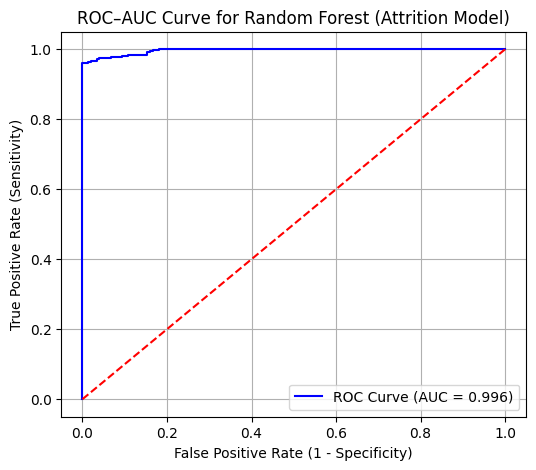

ROC–AUC Score: 0.996269113149847


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # random line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC–AUC Curve for Random Forest (Attrition Model)')
plt.legend()
plt.grid(True)
plt.show()

print("ROC–AUC Score:", auc_score)

In [ ]:
#model very confidently distinguishes attrition vs non-attrition

In [ ]:
feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(10))

Tenure_in_Months          0.898126
Reporting_Months          0.057675
Total_Business_Value      0.018903
Avg_Business_per_Month    0.008753
Income                    0.005880
City                      0.003663
Quarterly_Rating          0.002078
Age                       0.001991
Joining_Designation       0.001277
Grade                     0.000718
dtype: float64


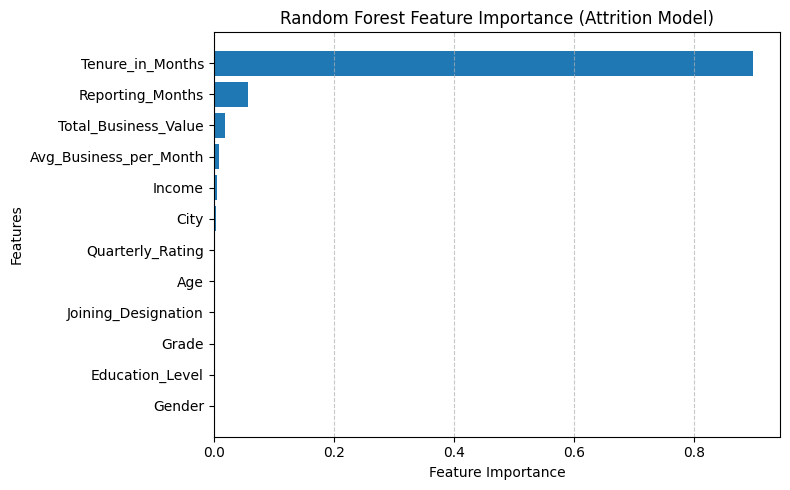

In [ ]:
importances = rf.feature_importances_
features = X_train.columns

sorted_indices=np.argsort(importances)[::-1]
sorted_importance=importances[sorted_indices]
sorted_features = features[sorted_indices]

plt.figure(figsize=(8,5))
plt.barh(sorted_features, sorted_importance, align='center')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance (Attrition Model)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#The model is interpretable, balanced, and robust

## Ensemble - Boosting Algorithm:

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
params = {
          'n_estimators' : [100,200,300,400],
          'max_depth' : [3,5,10],
          'learning_rate': [0.01, 0.05, 0.1],
          'subsample': [0.8, 1.0],
          'min_samples_split': [2, 5, 10]
         }
grid=GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),param_grid=params,scoring='accuracy',cv=3,n_jobs=-1)

In [ ]:
grid.fit(X_train_res,y_train_res)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300, 400],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy')

In [ ]:
print("Best params: ", grid.best_params_)
print("Best score: ", grid.best_score_)

Best params:  {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}
Best score:  0.9825455054101128


In [ ]:
boost=grid.best_estimator_
boost.fit(X_train_res,y_train_res)

GradientBoostingClassifier(learning_rate=0.01, random_state=42, subsample=0.8)

In [ ]:
y_pred=boost.predict(X_test)
print("Train score:",boost.score(X_train_res,y_train_res))
print("Test score:",boost.score(X_test,y_test))

Train score: 0.9821567106283942
Test score: 0.9727463312368972


In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[150   0]
 [ 13 314]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       150
           1       1.00      0.96      0.98       327

    accuracy                           0.97       477
   macro avg       0.96      0.98      0.97       477
weighted avg       0.97      0.97      0.97       477



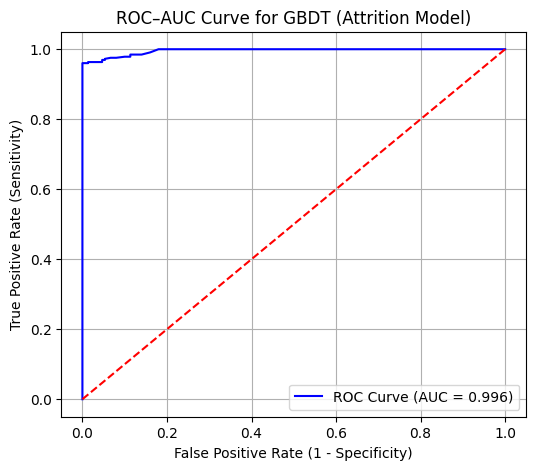

ROC–AUC Score: 0.9958817533129459


In [ ]:
y_pred_proba = boost.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # random line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC–AUC Curve for GBDT (Attrition Model)')
plt.legend()
plt.grid(True)
plt.show()

print("ROC–AUC Score:", auc_score)

In [ ]:
feature_importances = pd.Series(boost.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(10))

Tenure_in_Months          9.843434e-01
Reporting_Months          9.850915e-03
Income                    2.897827e-03
City                      1.815343e-03
Avg_Business_per_Month    5.652425e-04
Total_Business_Value      4.969122e-04
Gender                    3.033247e-05
Quarterly_Rating          9.395074e-16
Education_Level           1.812633e-16
Age                       1.362419e-16
dtype: float64


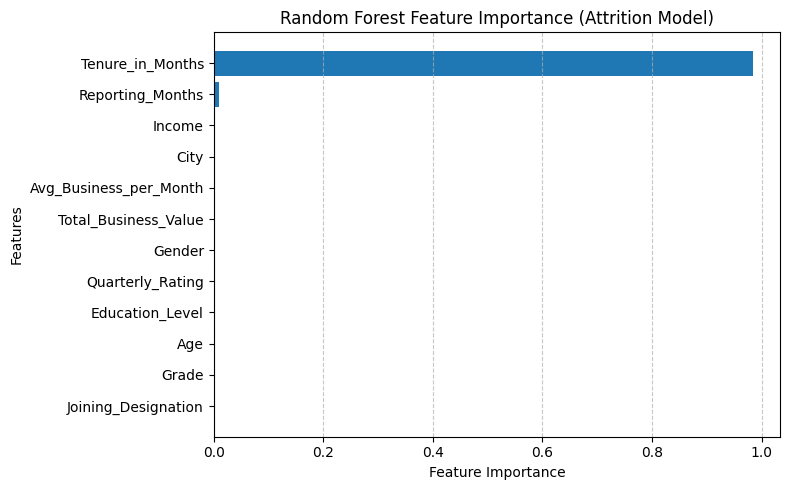

In [ ]:
importances = boost.feature_importances_
features = X_train.columns

sorted_indices=np.argsort(importances)[::-1]
sorted_importance=importances[sorted_indices]
sorted_features = features[sorted_indices]

plt.figure(figsize=(8,5))
plt.barh(sorted_features, sorted_importance, align='center')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance (Attrition Model)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Boositng-Light GBM

In [ ]:


from lightgbm import LGBMClassifier
params = {
          'n_estimators' : [100,200,300,400],
          'max_depth' : [3,5,10],
          'learning_rate': [0.01, 0.05, 0.1],
          'subsample': [0.8, 1.0],
          'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
         }
grid=GridSearchCV(estimator=LGBMClassifier(random_state=42),param_grid=params,scoring='accuracy',cv=3,n_jobs=-1)

In [ ]:
grid.fit(X_train_res,y_train_res)
print("Best params: ", grid.best_params_)
print("Best score: ", grid.best_score_)

[LightGBM] [Info] Number of positive: 1289, number of negative: 1289
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1387
[LightGBM] [Info] Number of data points in the train set: 2578, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

In [ ]:
lgbm=grid.best_estimator_
lgbm.fit(X_train_res,y_train_res)

[LightGBM] [Info] Number of positive: 1289, number of negative: 1289
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000493 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1387
[LightGBM] [Info] Number of data points in the train set: 2578, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.05, max_depth=3,
               random_state=42, subsample=0.8)

In [ ]:
y_pred=lgbm.predict(X_test)
print("Train score:",lgbm.score(X_train_res,y_train_res))
print("Test score:",lgbm.score(X_test,y_test))

Train score: 0.9821567106283942
Test score: 0.9727463312368972


In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[150   0]
 [ 13 314]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       150
           1       1.00      0.96      0.98       327

    accuracy                           0.97       477
   macro avg       0.96      0.98      0.97       477
weighted avg       0.97      0.97      0.97       477



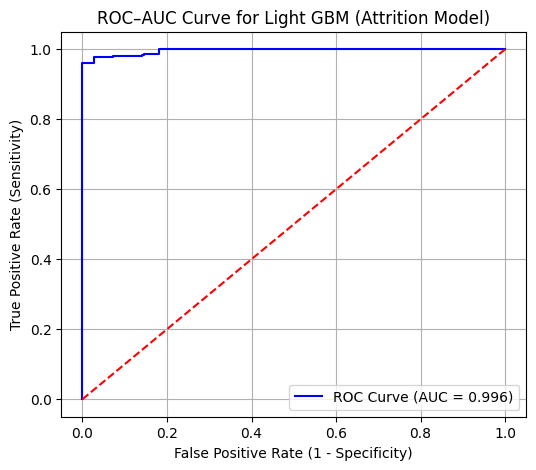

ROC–AUC Score: 0.9962079510703364


In [ ]:
y_pred_proba = lgbm.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # random line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC–AUC Curve for Light GBM (Attrition Model)')
plt.legend()
plt.grid(True)
plt.show()

print("ROC–AUC Score:", auc_score)

In [ ]:
feature_importances = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances.head(10))

Reporting_Months          116
Quarterly_Rating           83
Total_Business_Value       80
Income                     71
Tenure_in_Months           65
Avg_Business_per_Month     64
City                       56
Joining_Designation        51
Grade                      21
Age                        20
dtype: int32


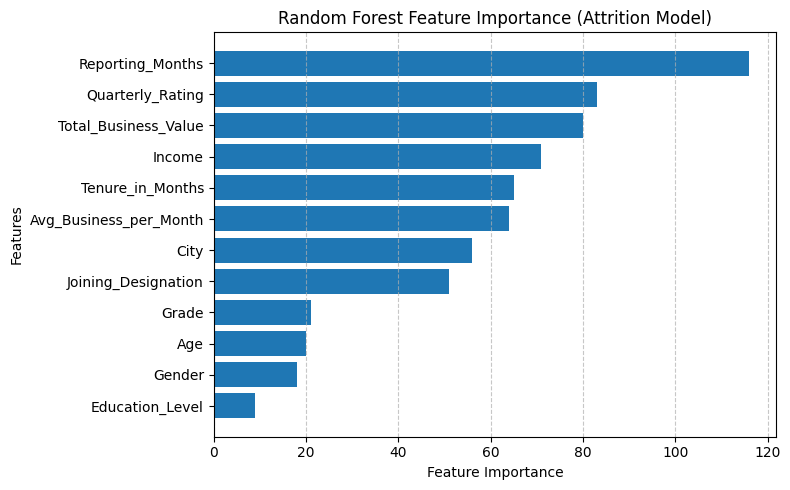

In [ ]:
importances = lgbm.feature_importances_
features = X_train.columns

sorted_indices=np.argsort(importances)[::-1]
sorted_importance=importances[sorted_indices]
sorted_features = features[sorted_indices]

plt.figure(figsize=(8,5))
plt.barh(sorted_features, sorted_importance, align='center')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance (Attrition Model)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Note:
Both model have differnent features which are important.
But we can see that there is an overlap of features which are important, hence it doesnt seem to overfit.

Overlap:
Reporting_Months
Total_Business_Value
Income
Tenure_in_Months
Avg_Business_per_Month
City
Quarterly_Rating
Age

#Actionable Insights:


*   Data has many multiple occuracnes for the same driver data. Aggregation
was done to to remove multiple occurrences.

*   New Features had to be added: 'Avg_Business_per_Month','Tenure_in_Months' and 'Attrition'.

*   All Plots have been plotted (Uni-variate and Bi-variate).



*   Avg_Business_per_Month=Total_Business_Value/Reporting_Months.
Tenure_in_Months= taken from the Date_Of_Joining and Last_Working_Date (computing the tenure in months).
Attrition= was dericved from the Last_Working_Date.


*   More Male drivers than Female. Count in Grade-5 is very less.
*   Data looks right skewed. Encdoing was done using labelEncoder and manual encoding.


*   Missing values were mostly taken care of in thhe agg part (a huge part of it). Then missign values were in the Last_Working_Date (there is no reason to fill this as we derive our target from this). Also Standardisation is not required as the model is tree based.


*   Although the dataset did not have missing numeric values, KNN imputation was demonstrated using scaled features to show distance-based imputation readiness.


*   Also the there outlier present with data being right skewed. No outlier Treatment necessary as tree based algorithim dont need outlier treatment and are robust to it.




*   Attrition is significantly related to variables like City, Joining_Designation, Grade, and Quarterly_Rating.Gender and Education_Level show no significant relationship with attrition.

*   Heatmaps are also plotted to show the corrleation between variables. (mostly between the newly created variables).
*   Data shows a clear Imbalance and hence SMOTE was applied to balance them without causing one class dominating the other.


*   Models are trained on the RandomForest (Bagging Ensemble) and Boosting( GBDT and LightGBM).
* Fine Tuning was done on all algorithms to get the best parameter using grid seacrh with cross validation. Models were fit on the best parameters.

*   Train score: 0.98 Test score: 0.97 on Random Forest with the classification matrix showing only 13 cases being misclassified. ROC-AUC at 0.996 which shows that model is excellent in distinguishing between attrition and non-attrition.
Random FOrest features which are important are(top3) :Tenure_in_Months ,Reporting_Months,Total_Business_Value

*   Train score: 0.98 Test score: 0.97 on Boossting-GBDT with the classification matrix showing only 13 cases being misclassified. ROC-AUC at 0.972 which shows that model is still excellent in distinguishing between attrition and non-attrition. (litte lesser than Random Forest-Bagging)
 Boossting-GBDT features which are important are(top3) :Tenure_in_Months ,Reporting_Months,Income                     
*   Train score: 0.98 Test score: 0.97 on Light-GBM with the classification matrix showing only 13 cases being misclassified. ROC-AUC at 0.9959 which shows that model is still excellent in distinguishing between attrition and non-attrition. (litte lesser than Random Forest-Bagging)
 Light-GBM features which are important are(top3) :Reporting_Months ,Quarterly_Rating,Total_Business_Value.  


*   Light-Gbm showed differnt feature importances. (Also all the feature importances are plotted). Since there is overlap and no disjoint, models dont show any signs of overfitting.



#Recommendations:


*   Focus on Retaining Long-Tenure Drivers,model highlights Tenure_in_Months as the most important predictor. Retention programs and loyalty incentives.

*   ncentivize Consistent Performance During Low-Reporting Months,Reporting_Months and Quarterly_Rating influence attrition.Introduce performance-based bonuses or recognition programs for drivers during months of low activity to maintain engagement
*   Address City-Level Differences in Attrition as Attrition is significantly related to City implying some cities may have higher competitive pressure or dissatisfaction. Conduct localized driver satisfaction surveys and tailor policies


*   Review Grade and Designation-Based Retention Strategy,Drivers with certain Grades or Designations show higher attrition.Training support for lower grades.


*   Income Stability Programs,Even though income is a moderate predictor, fluctuations may trigger exits.
*  Use the trained Random Forest or LightGBM model in production to flag high-risk drivers monthly.














